# **Cybersecurity Network Traffic Dataset: Preprocessing**

This dataset contains **network traffic records used for cybersecurity analysis**, specifically focused on detecting **Distributed Denial of Service (DDoS) and network flooding attacks**.  
Each CSV file represents traffic captured during a **specific attack type or normal network behavior**.


The dataset is divided into multiple CSV files, each corresponding to a specific attack category or normal traffic type.

| File | Description |
|-----|-------------|
| `DrDoS_DNS.csv` | DNS amplification Distributed Reflection Denial of Service attack traffic |
| `DrDoS_LDAP.csv` | LDAP reflection DDoS attack traffic |
| `DrDoS_MSSQL.csv` | MSSQL reflection DDoS attack traffic |
| `DrDoS_NetBIOS.csv` | NetBIOS reflection DDoS attack traffic |
| `DrDoS_NTP.csv` | NTP amplification attack traffic |
| `DrDoS_SNMP.csv` | SNMP reflection DDoS attack traffic |
| `DrDoS_SSDP.csv` | SSDP reflection DDoS attack traffic |
| `DrDoS_UDP.csv` | UDP flood distributed denial of service traffic |
| `Syn.csv` | SYN flood attack traffic |

These attack types are examples of volumetric or reflection-based DDoS attacks, where attackers overwhelm a server or network by generating massive traffic.

For training, we only consider the following CSV files due to limited computational resources. These CSV files were selected because these traffic types are commonly associated with reflection and amplification attacks. In these attacks, the attacker sends spoofed requests to legitimate servers (such as DNS, LDAP, or NTP services). The source IP address is forged to appear as the victim's address. As a result, the legitimate server sends the response to the victim instead of the attacker. Therefore, the analysis will focus on the following datasets:

- **DNS.csv**
- **LDAP.csv**
- **NTP.csv**
- **Syn.csv**




### **00 Libraries**

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### **01 Load Dataset**

In [2]:
PATH = "clean_data/"

In [3]:
def load_datasets(directory: str) -> pd.DataFrame:

    dfs = []

    for file in os.listdir(directory):

        if file.endswith(".csv"):

            print(f"Loading {file}...")

            path = os.path.join(directory, file)

            df = pd.read_csv(path)

            # keep track of dataset origin
            df["source_dataset"] = file

            dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    return df_all

In [4]:
df = load_datasets(PATH)

Loading DrDoS_DNS_clean.csv...
Loading DrDoS_LDAP_clean.csv...
Loading DrDoS_NTP_clean.csv...
Loading Syn_clean.csv...


In [5]:
df.head()

,Unnamed: 0,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound,Label,source_dataset
0,425,634,60495,17,28415,97,0,42680.0,0.0,440.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,DrDoS_DNS_clean.csv
1,430,634,60495,17,2,2,0,880.0,0.0,440.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_DNS_clean.csv
2,1654,634,46391,17,48549,200,0,88000.0,0.0,440.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,DrDoS_DNS_clean.csv
3,2927,634,11894,17,48337,200,0,88000.0,0.0,440.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,DrDoS_DNS_clean.csv
4,694,634,27878,17,32026,200,0,88000.0,0.0,440.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,DrDoS_DNS_clean.csv


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9644481 entries, 0 to 9644480
Data columns (total 65 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Unnamed: 0                   int64  
 1   Source Port                  int64  
 2   Destination Port             int64  
 3   Protocol                     int64  
 4   Flow Duration                int64  
 5   Total Fwd Packets            int64  
 6   Total Backward Packets       int64  
 7   Total Length of Fwd Packets  float64
 8   Total Length of Bwd Packets  float64
 9   Fwd Packet Length Max        float64
 10  Fwd Packet Length Min        float64
 11  Fwd Packet Length Mean       float64
 12  Fwd Packet Length Std        float64
 13  Bwd Packet Length Max        float64
 14  Bwd Packet Length Min        float64
 15  Bwd Packet Length Mean       float64
 16  Bwd Packet Length Std        float64
 17  Flow Bytes/s                 float64
 18  Flow Packets/s               float64
 19  

### **1.Distribution after concatenation (Original Dataset)**

In [7]:
def plot_label_distribution(df):
    
    counts = df["Label"].value_counts().sort_index()
    
    print("Label counts:")
    for label, count in counts.items():
        print(f"Label {label}: {count}")

    counts.plot(kind="bar")

Label counts:
Label 0: 19577
Label 1: 9624904


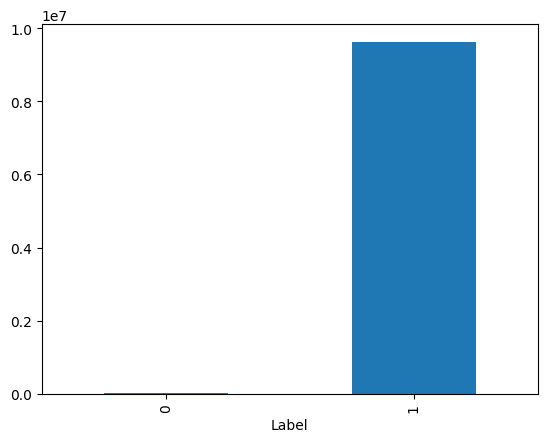

In [8]:
plot_label_distribution(df)

In [36]:
def plot_columns_distribution(
    df: pd.DataFrame,
    columns: list[str],
    title: str,
    sample_size: int = 100000
):
    
    sample = df.sample(min(len(df), sample_size))

    n = len(columns)
    rows = (n + 2) // 4
    cols = 4

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):

        ax = axes[i]

        if pd.api.types.is_numeric_dtype(sample[column]):
            sns.histplot(
                sample[column],
                bins=50,
                kde=True,
                ax=ax,
                color="#ff69b4"   # pink
            )

        else:
            counts = sample[column].value_counts()
            sns.barplot(
                x=counts.index,
                y=counts.values,
                ax=ax,
                color="#ff69b4"
            )

        ax.set_title(f"{column}")
        ax.set_xlabel(column)
        ax.set_ylabel("Frequency")
        ax.tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Global title
    fig.suptitle(title, fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## **2. Split into Train and Testing**

After the preprocessing stage, all cleaned datasets were **concatenated into a single unified dataset**. This combined dataset is then divided into **training and testing subsets** to support model development and evaluation.

The split is performed using an **80–20 ratio**, where:

- **80% of the data** is used for **training**
- **20% of the data** is reserved for **testing**

To preserve the original class distribution between **benign and malicious traffic**, the split is performed using **stratified sampling** based on the `Label` column. This ensures that both subsets maintain the same proportion of classes.

The **training dataset** will subsequently undergo an **undersampling technique** to address the strong class imbalance present in the dataset. This step reduces the number of samples from the majority class, helping the model learn meaningful patterns from both classes.

The **testing dataset** remains untouched and will be used exclusively to **evaluate the final model performance**. Keeping the test set unchanged ensures an unbiased assessment of the model's ability to generalize to unseen data.

In [19]:
RANDOM_STATE = 42

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Label"],
    random_state=RANDOM_STATE
)

In [20]:
print("Train distribution:")
print(train_df["Label"].value_counts(normalize=True))

print("\nTest distribution:")
print(test_df["Label"].value_counts(normalize=True))

Train distribution:
Label
1    0.99797
0    0.00203
Name: proportion, dtype: float64

Test distribution:
Label
1    0.99797
0    0.00203
Name: proportion, dtype: float64


After splitting the dataset into training and testing subsets using stratified sampling, both sets preserve the original class distribution of the dataset.

| Dataset | Malicious (1) | Benign (0) |
|--------|---------------|-----------|
| Train | 99.797% | 0.203% |
| Test | 99.797% | 0.203% |

This result confirms that the stratified split successfully maintained the same proportion of classes in both subsets. Maintaining this distribution is important to ensure that the test set accurately represents the data seen during training.

* The **training dataset** will subsequently undergo an **undersampling technique** to address the strong class imbalance present in the dataset. This step reduces the number of samples from the majority class, helping the model learn meaningful patterns from both classes.

* The **test dataset will remain unchanged** and will be used only to **evaluate the final model performance**, ensuring that the evaluation reflects the real-world distribution of the data.

## **3. Balanced Training Dataset: Undersampling**

The function `create_balanced_training_dataset` is used to construct a balanced training dataset from the original data.

First, the dataset is separated into two subsets based on the `Label` column:

- **Benign traffic (Label = 0)**
- **Attack traffic (Label = 1)**

Since **benign traffic represents the minority class**, the number of benign samples determines the target size for both classe in the balanced dataset.

All benign samples are retained, and an equal number of attack samples is selected. To ensure that different attack types remain properly represented, stratified sampling is applied based on the `source_dataset` column. This guarantees that attack samples are drawn proportionally from the different datasets (e.g., DNS, LDAP, NTP, SYN).

Finally, the benign and sampled attack instances are concatenated to form a **balanced training dataset**, where both classes contain the same number of samples. This balanced dataset is then used for model training to mitigate the effects of the strong class imbalance present in the original data.

In [22]:
def create_balanced_training_set(
    df: pd.DataFrame,
    label_col: str = "Label",
    source_col: str = "source_dataset",
    random_state: int = RANDOM_STATE
) -> pd.DataFrame:

    # Separate classes
    benign = df[df[label_col] == 0]
    attacks = df[df[label_col] == 1]

    # Number of benign samples (minority class)
    n_benign = len(benign)

    # Stratified sampling of attacks based on dataset source
    attack_sample = (
        attacks
        .groupby(source_col, group_keys=False)
        .apply(lambda x: x.sample(
            n=min(int(n_benign * len(x) / len(attacks)), len(x)),
            random_state=random_state
        ))
    )

    # If rounding caused fewer samples, fill the remaining
    remaining = n_benign - len(attack_sample)
    if remaining > 0:
        extra = attacks.drop(attack_sample.index).sample(
            n=remaining,
            random_state=random_state
        )
        attack_sample = pd.concat([attack_sample, extra])

    # Combine benign + attacks
    balanced_df = pd.concat([benign, attack_sample], ignore_index=True)

    # Shuffle dataset
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    return balanced_df

In [23]:
balanced_train_df = create_balanced_training_set(train_df)

C:\Users\Ale\AppData\Local\Temp\ipykernel_21360\4052458470.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [33]:
balanced_train_df.shape

(31324, 65)

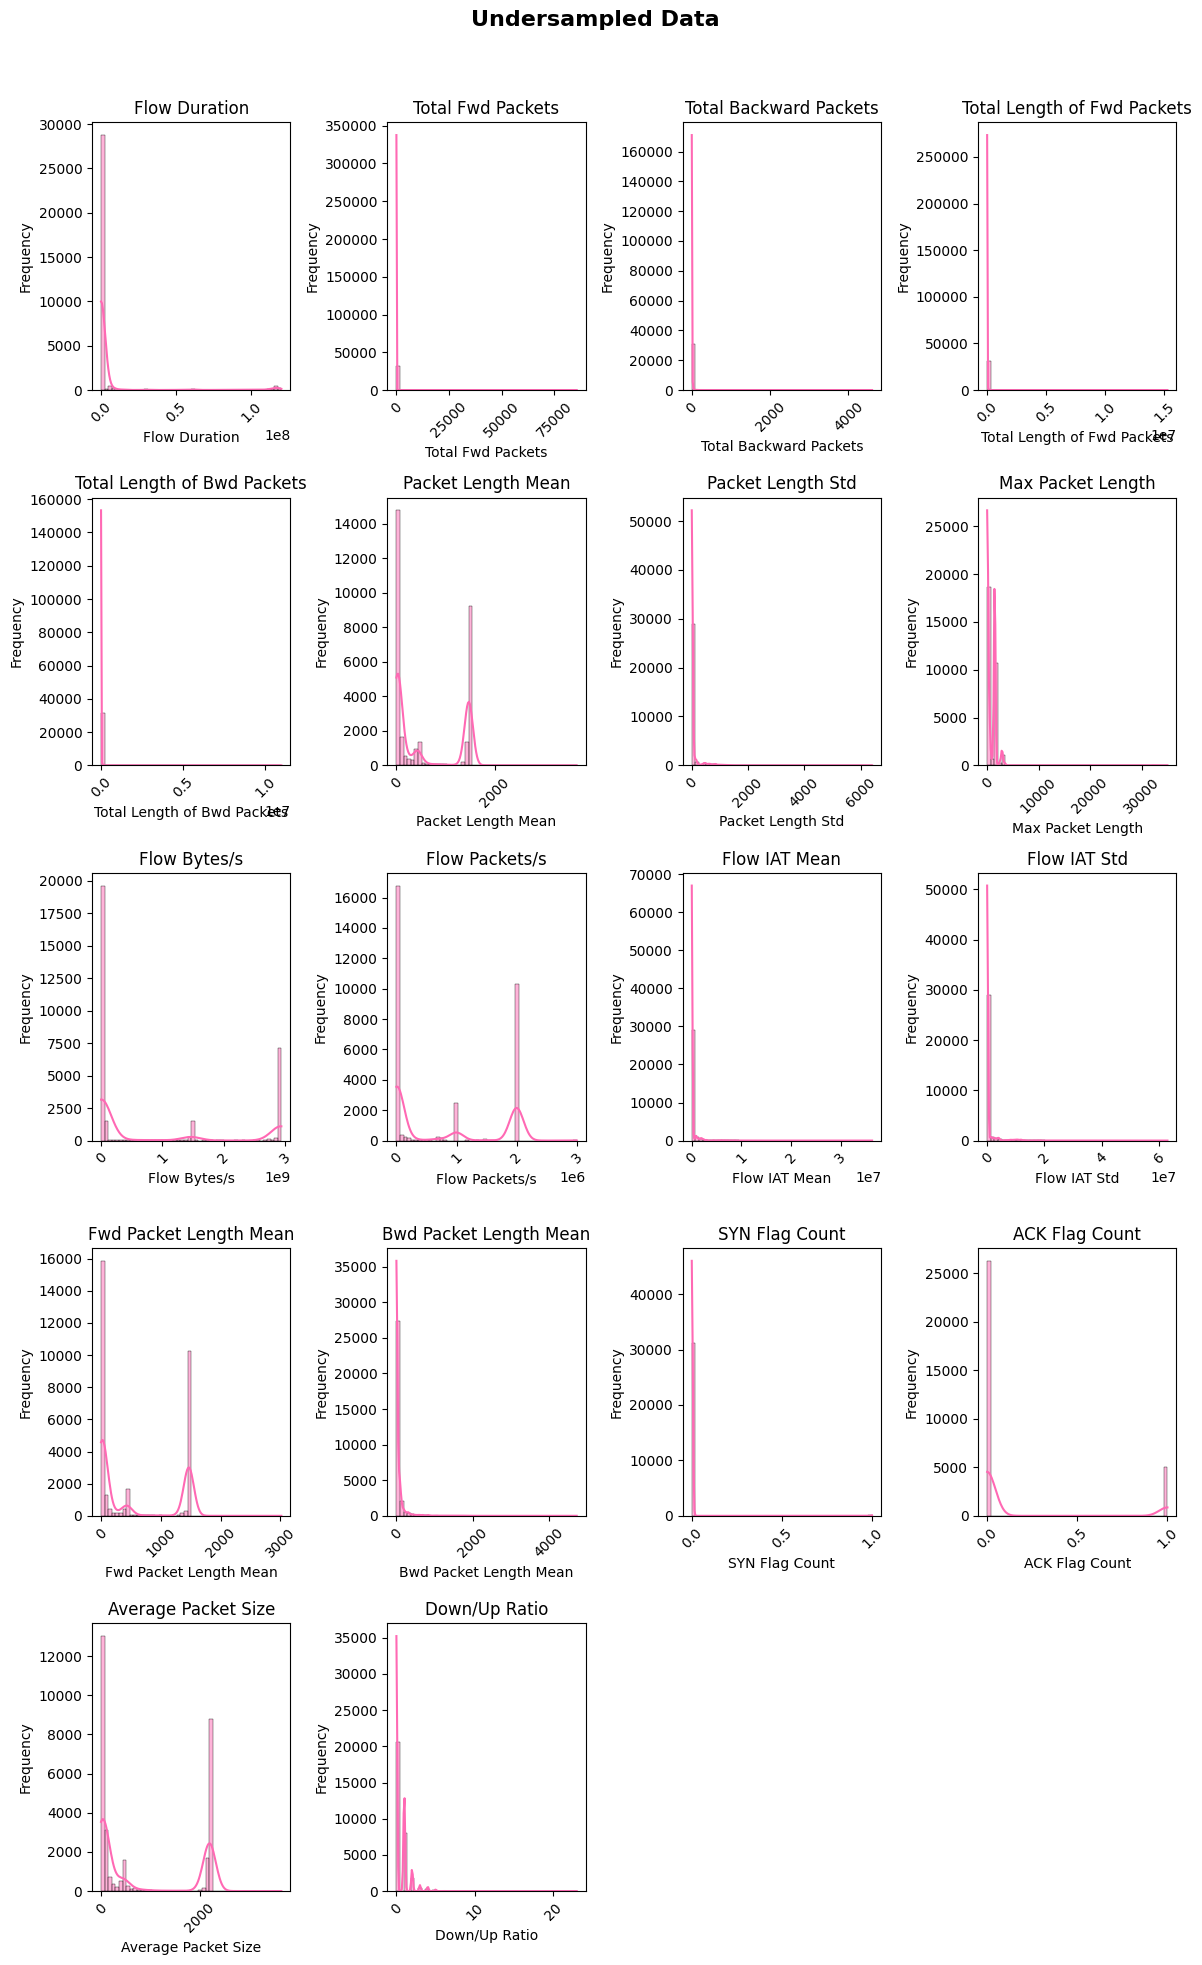

In [37]:
columns_to_plot = [
    # Flow duration
    "Flow Duration",

    # Packet counts
    "Total Fwd Packets",
    "Total Backward Packets",

    # Packet lengths
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",

    # Packet size statistics
    "Packet Length Mean",
    "Packet Length Std",
    "Max Packet Length",

    # Traffic rate
    "Flow Bytes/s",
    "Flow Packets/s",

    # Inter-arrival times
    "Flow IAT Mean",
    "Flow IAT Std",

    # Directional packet size
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",

    # TCP flags
    "SYN Flag Count",
    "ACK Flag Count",

    # Overall packet characteristics
    "Average Packet Size",

    # Flow behavior
    "Down/Up Ratio"
]


plot_columns_distribution(balanced_train_df, columns_to_plot, "Undersampled Data")

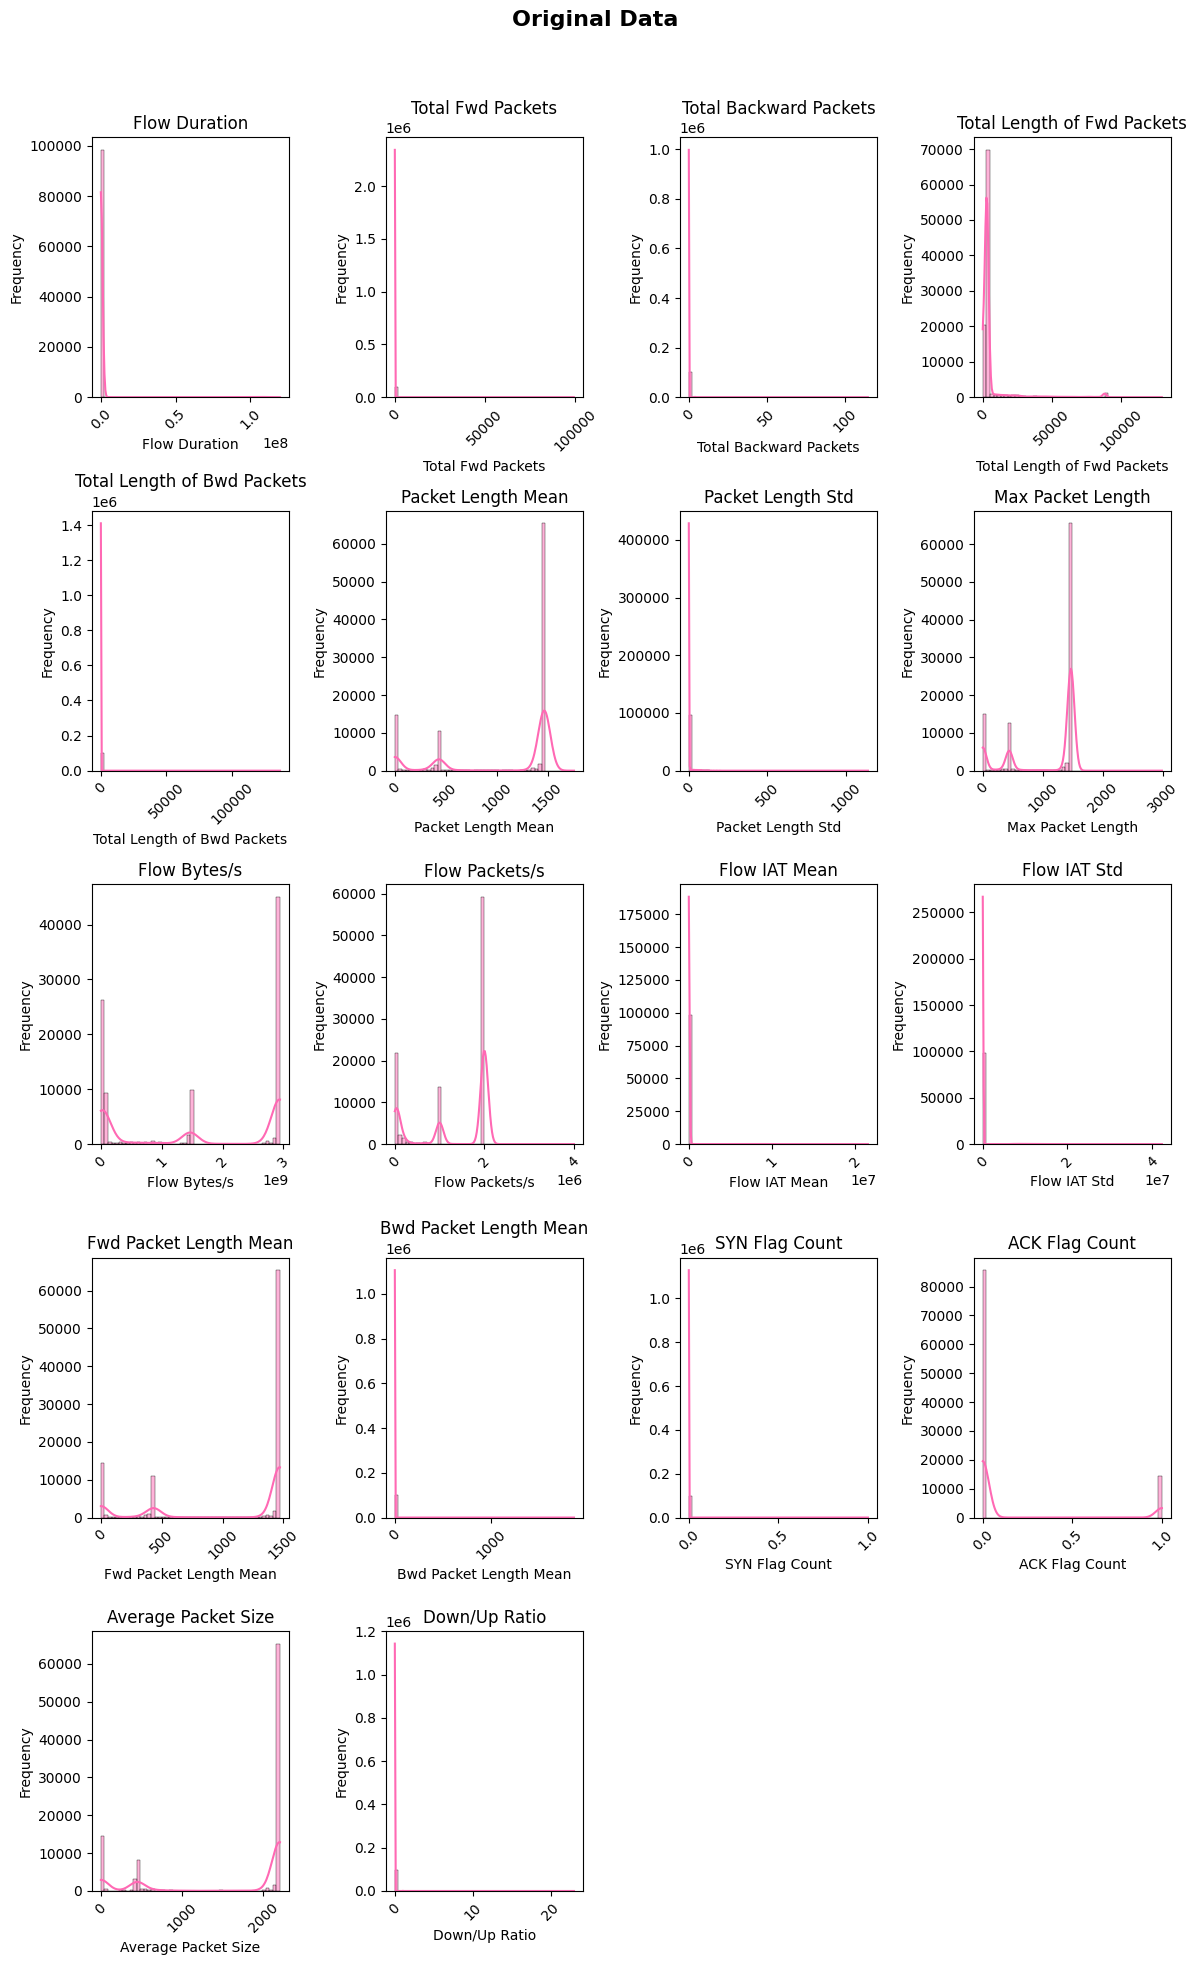

In [38]:
plot_columns_distribution(df, columns_to_plot, "Original Data")


The similarity in distribution shapes indicates that the undersampling procedure did not distort the statistical characteristics of the dataset. The balanced dataset preserves the same behavioral patterns present in the original traffic data.

In [34]:
def save_preprocessed_dataset(
    df: pd.DataFrame,
    filename: str,
    directory: str = "preprocessed_data"
) -> None:

    if not os.path.exists(directory):
        os.makedirs(directory)

    path = os.path.join(directory, filename)
    df.to_csv(path, index=False)

    print(f"Dataset saved to: {path}")
    print(f"Shape: {df.shape}")

### **Saving the Preprocessed Datasets**

After completing the preprocessing and balancing steps, the datasets were stored for use in the baseline modeling stage. Two datasets were saved:

- **Training dataset (`train`)** – contains the balanced data generated through the undersampling procedure.
- **Testing dataset (`test`)** – contains the untouched portion of the data reserved for model evaluation.

The datasets were saved in the `preprocessed_data` directory to ensure a clear separation between raw data and processed data used in the machine learning pipeline.

| Dataset | Shape | Description |
|-------|-------|-------------|
| Train | (31,324, 65) | Balanced dataset used for model training |
| Test | (1,928,897, 65) | Original distribution dataset used for evaluation |

The training dataset is significantly smaller because it results from the undersampling process applied to address the severe class imbalance present in the original data. In contrast, the test dataset retains the original distribution of classes to provide an unbiased evaluation of model performance under realistic conditions.

In [35]:
save_preprocessed_dataset(balanced_train_df, "train")
save_preprocessed_dataset(test_df, "test")

Dataset saved to: preprocessed_data\train
Shape: (31324, 65)
Dataset saved to: preprocessed_data\test
Shape: (1928897, 65)
